Imports & Load


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('data/engineered_data.csv')
features = pd.read_csv('data/selected_features.txt',
                        header=None)[0].tolist()
features = [f for f in features if f in df.columns]

X = df[features].fillna(0)
feature_names = X.columns.tolist()
y = df['log_shares'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target mean: {y.mean():.3f} | std: {y.std():.3f}")

Train: (30769, 68) | Test: (7693, 68)
Target mean: 7.470 | std: 0.925


Define Models

In [18]:
regressors = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', Lasso(alpha=0.001, max_iter=5000, random_state=42))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', ElasticNet(alpha=0.001, l1_ratio=0.5,
                           max_iter=5000, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', KNeighborsRegressor(n_neighbors=11))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('reg', SVR(kernel='rbf', C=1.0, epsilon=0.1))
    ]),
    'Decision Tree': Pipeline([
        ('reg', DecisionTreeRegressor(max_depth=8, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('reg', RandomForestRegressor(n_estimators=200,
                                       random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('reg', XGBRegressor(n_estimators=200, learning_rate=0.05,
                              max_depth=6, random_state=42, n_jobs=-1))
    ])
}

print(f"Total models defined: {len(regressors)}")
for name in regressors:
    print(f"  - {name}")

Total models defined: 9
  - Linear Regression
  - Ridge
  - Lasso
  - ElasticNet
  - KNN
  - SVR
  - Decision Tree
  - Random Forest
  - XGBoost


Evaluation Function

In [19]:
def adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate_regressor(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    n, p = X_te.shape
    r2 = r2_score(y_te, y_pred)
    return {
        'MAE':     mean_absolute_error(y_te, y_pred),
        'MSE':     mean_squared_error(y_te, y_pred),
        'RMSE':    np.sqrt(mean_squared_error(y_te, y_pred)),
        'R2':      r2,
        'Adj_R2':  adj_r2(r2, n, p)
    }, y_pred

print("Evaluation function ready ")

Evaluation function ready 


Cross Validation

Running 5-Fold Cross Validation...

Linear Regression     R²: 0.1306 ± 0.0072
Ridge                 R²: 0.1308 ± 0.0071
Lasso                 R²: 0.1309 ± 0.0069
ElasticNet            R²: 0.1309 ± 0.0070
KNN                   R²: 0.0804 ± 0.0087
SVR                   R²: 0.1195 ± 0.0069
Decision Tree         R²: 0.0348 ± 0.0207
Random Forest         R²: 0.1526 ± 0.0111
XGBoost               R²: 0.1683 ± 0.0093


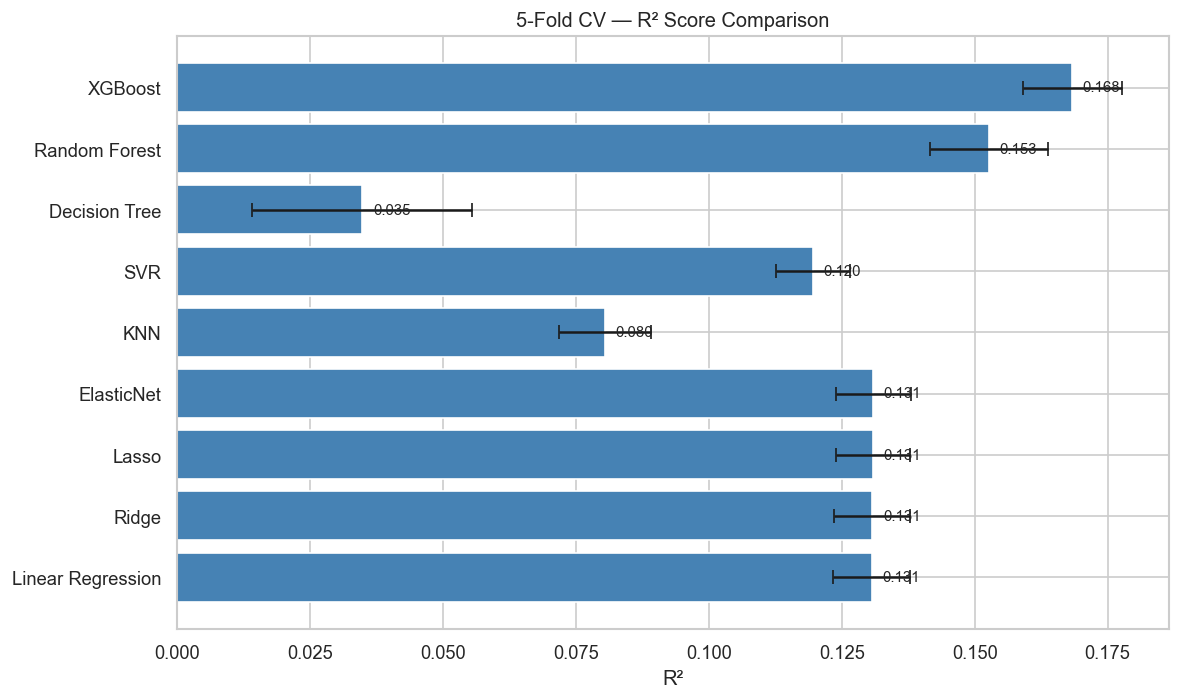

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Running 5-Fold Cross Validation...\n")
for name, model in regressors.items():
    scores = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s}  R²: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]

bars = ax.barh(names, means, xerr=stds, color='steelblue',
               edgecolor='white', capsize=4)
for bar, m in zip(bars, means):
    ax.text(m + 0.002, bar.get_y() + bar.get_height()/2,
            f'{m:.3f}', va='center', fontsize=9)
ax.set_title('5-Fold CV — R² Score Comparison')
ax.set_xlabel('R²')
plt.tight_layout()
plt.show()

Train & Evaluate All Models

In [21]:
reg_metrics = {}
reg_preds   = {}

for name, model in regressors.items():
    m, yp = evaluate_regressor(
        model, X_train, y_train, X_test, y_test)
    reg_metrics[name] = m
    reg_preds[name]   = yp
    print(f"{name:20s}  R²={m['R2']:.4f}  "
          f"RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}")

reg_df = pd.DataFrame(reg_metrics).T.round(4)
print("\n", reg_df)
reg_df.to_csv('results/regression_metrics.csv')
print("\n Saved → results/regression_metrics.csv")

Linear Regression     R²=0.1251  RMSE=0.8729  MAE=0.6418
Ridge                 R²=0.1251  RMSE=0.8729  MAE=0.6418
Lasso                 R²=0.1261  RMSE=0.8724  MAE=0.6416
ElasticNet            R²=0.1260  RMSE=0.8725  MAE=0.6415
KNN                   R²=0.0569  RMSE=0.9063  MAE=0.6619
SVR                   R²=0.1100  RMSE=0.8804  MAE=0.6219
Decision Tree         R²=0.0546  RMSE=0.9074  MAE=0.6604
Random Forest         R²=0.1522  RMSE=0.8593  MAE=0.6361
XGBoost               R²=0.1577  RMSE=0.8565  MAE=0.6272

                       MAE     MSE    RMSE      R2  Adj_R2
Linear Regression  0.6418  0.7619  0.8729  0.1251  0.1173
Ridge              0.6418  0.7619  0.8729  0.1251  0.1173
Lasso              0.6416  0.7611  0.8724  0.1261  0.1183
ElasticNet         0.6415  0.7612  0.8725  0.1260  0.1182
KNN                0.6619  0.8214  0.9063  0.0569  0.0485
SVR                0.6219  0.7751  0.8804  0.1100  0.1021
Decision Tree      0.6604  0.8233  0.9074  0.0546  0.0462
Random Forest      0.

Metrics Comparison Plot

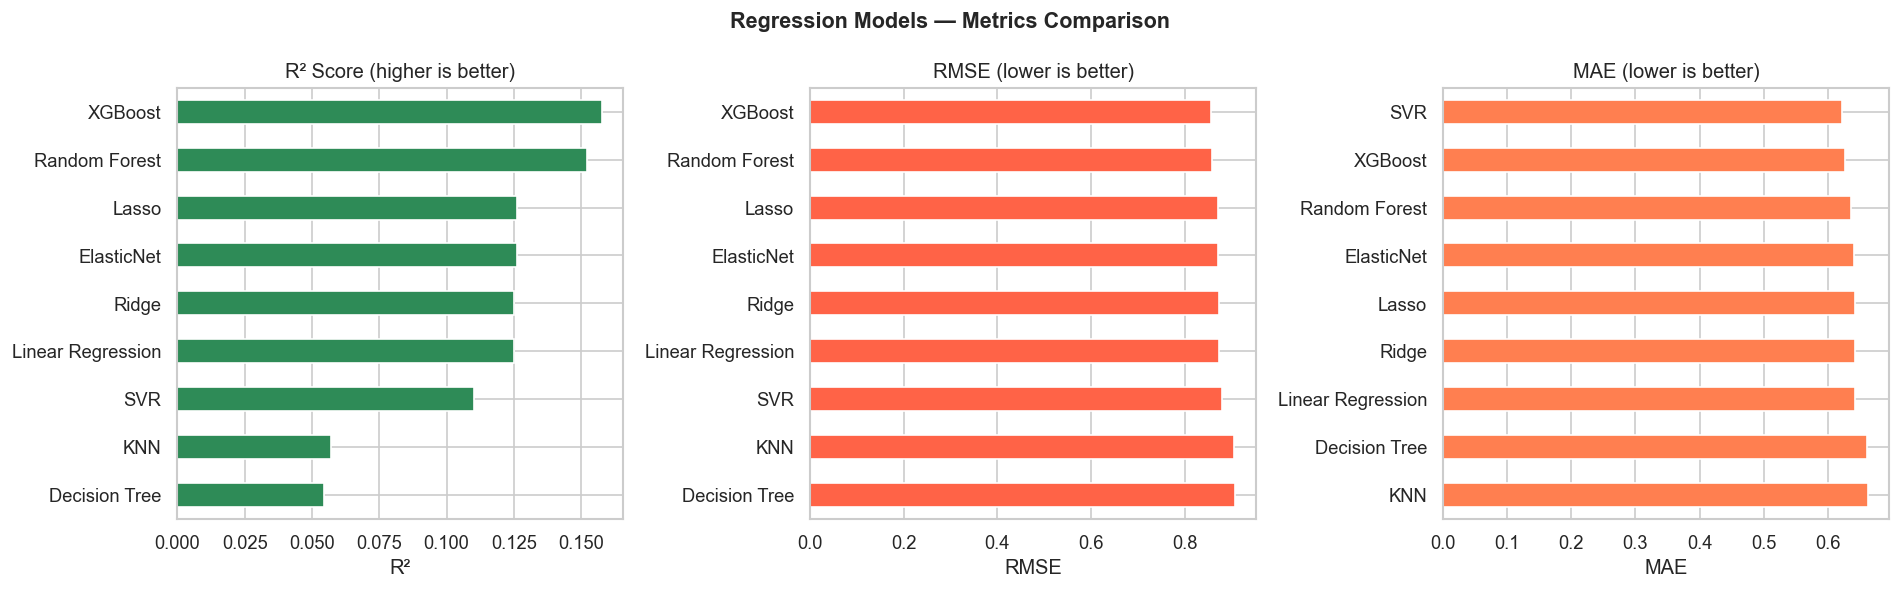

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

reg_df['R2'].sort_values().plot(
    kind='barh', ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('R² Score (higher is better)')
axes[0].set_xlabel('R²')

reg_df['RMSE'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xlabel('RMSE')

reg_df['MAE'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('MAE (lower is better)')
axes[2].set_xlabel('MAE')

plt.suptitle('Regression Models — Metrics Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Actual vs Predicted

Best model: XGBoost


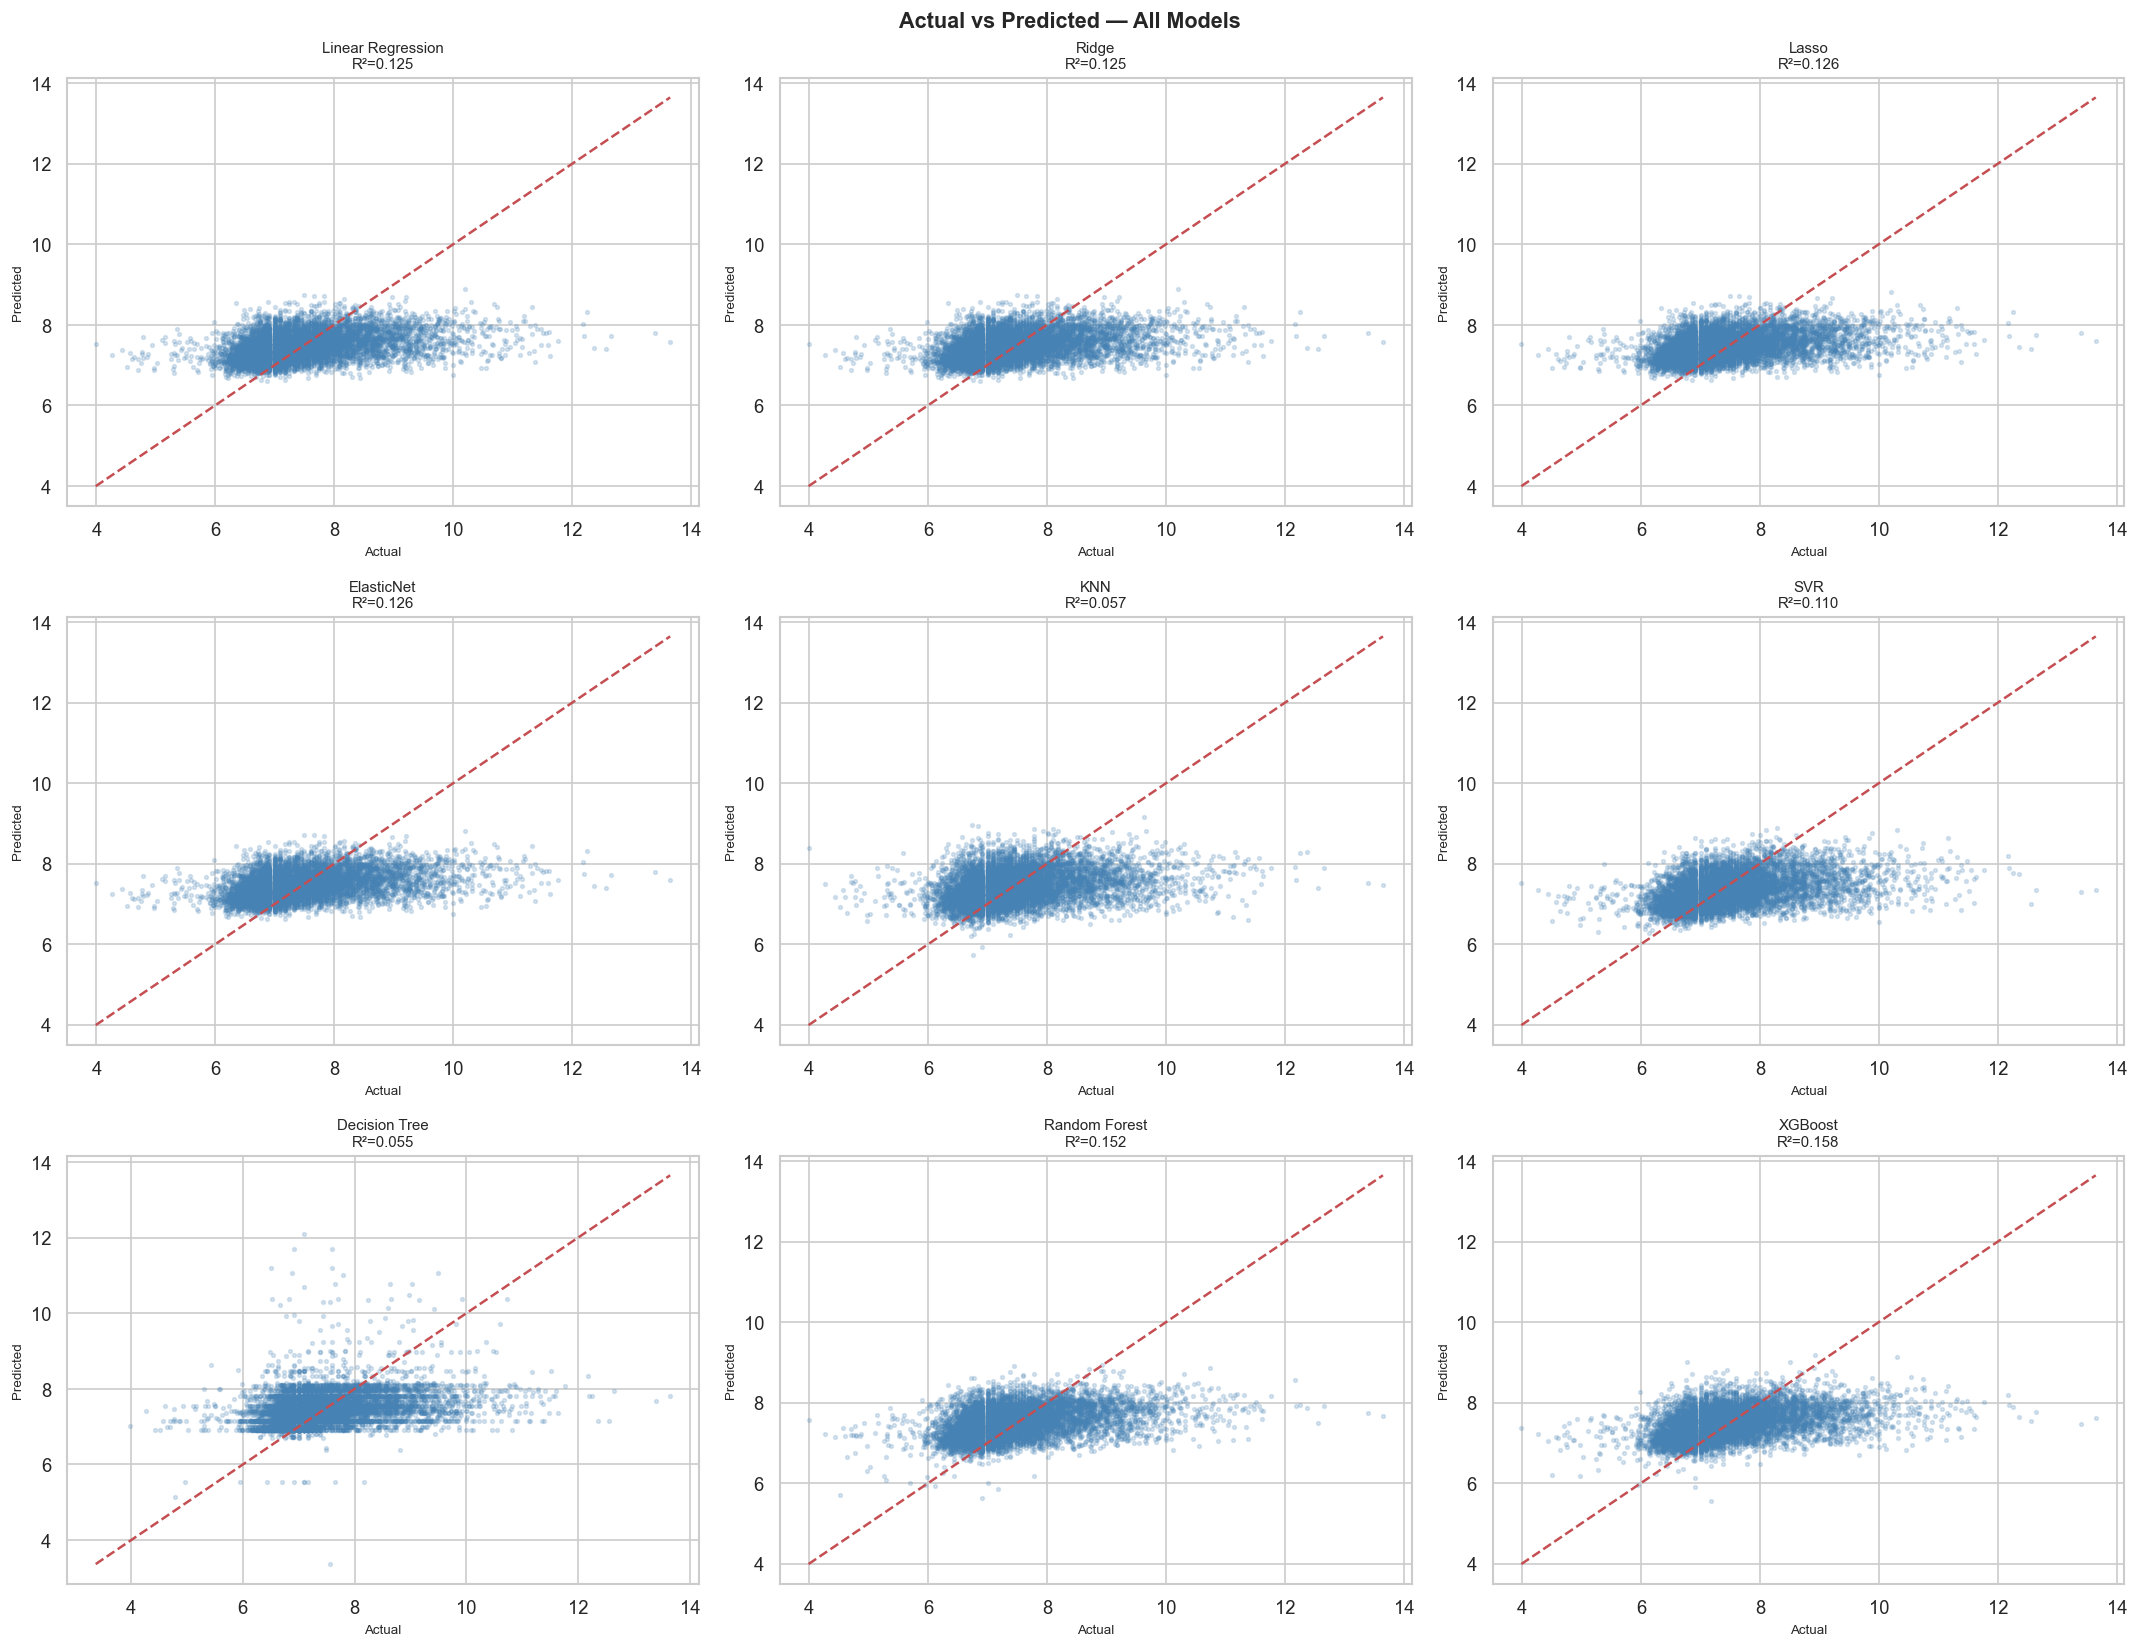

In [23]:
best_reg = reg_df['R2'].idxmax()
print(f"Best model: {best_reg}")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(reg_preds.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.2, s=5, color='steelblue')
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    axes[i].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    r2 = reg_metrics[name]['R2']
    axes[i].set_title(f'{name}\nR²={r2:.3f}', fontsize=9)
    axes[i].set_xlabel('Actual', fontsize=8)
    axes[i].set_ylabel('Predicted', fontsize=8)

plt.suptitle('Actual vs Predicted — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Residual Analysis

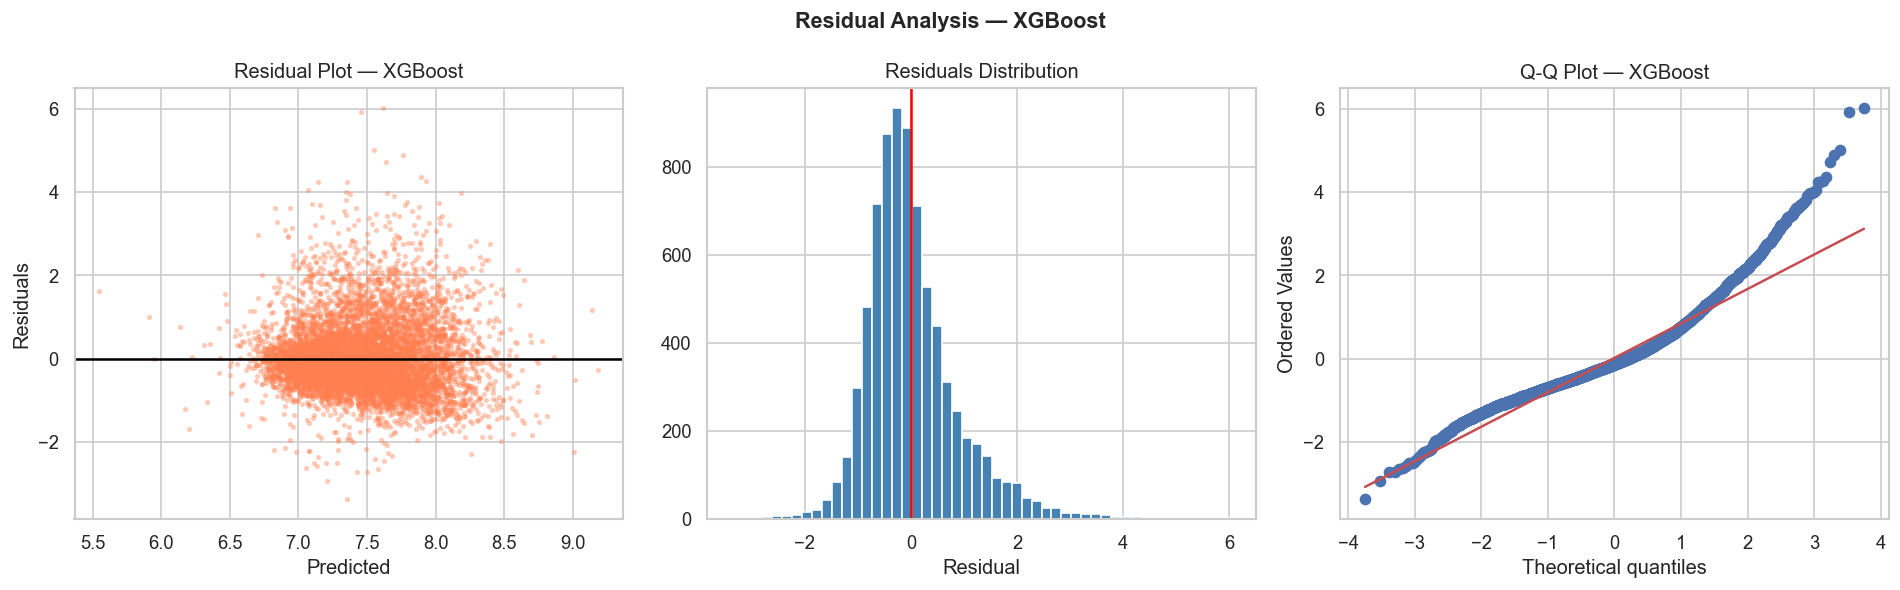

Heteroscedasticity correlation: 0.193 (p=0.0000)
Residual mean: 0.0191
Residual std:  0.8563


In [24]:
best_pred = reg_preds[best_reg]
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residual plot
axes[0].scatter(best_pred, residuals, alpha=0.3, s=5, color='coral')
axes[0].axhline(0, color='black', lw=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residual Plot — {best_reg}')

# Histogram of residuals
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual')

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title(f'Q-Q Plot — {best_reg}')

plt.suptitle(f'Residual Analysis — {best_reg}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr_bp, p_bp = stats.pearsonr(best_pred, np.abs(residuals))
print(f"Heteroscedasticity correlation: {corr_bp:.3f} (p={p_bp:.4f})")
print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")

Wilcoxon Test

Wilcoxon Test: XGBoost vs Random Forest
  Statistic = 0.0000
  P-value   = 0.0625
  Significant difference (p<0.05): False


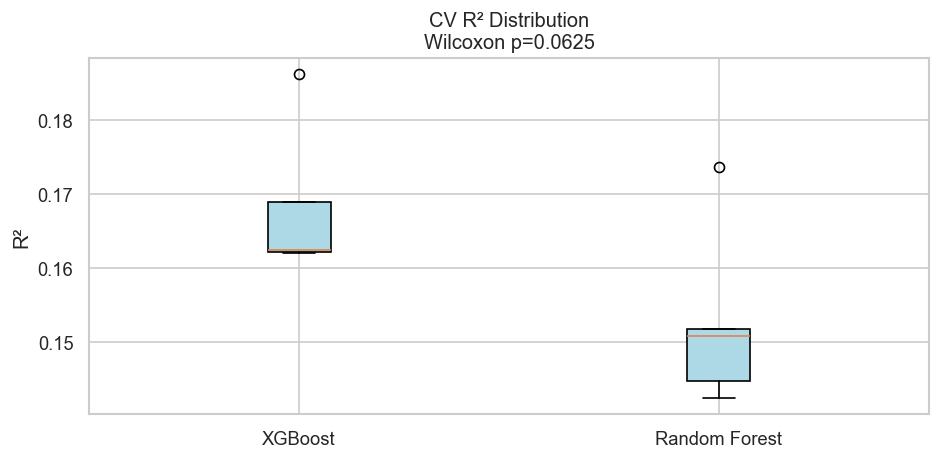

In [25]:
from scipy.stats import wilcoxon

cv_scores_all = {}
for name, model in regressors.items():
    sc = cross_val_score(model, X_train, y_train,
                          cv=cv, scoring='r2', n_jobs=-1)
    cv_scores_all[name] = sc

best1 = reg_df['R2'].nlargest(1).index[0]
best2 = reg_df['R2'].nlargest(2).index[1]

stat, p = wilcoxon(cv_scores_all[best1], cv_scores_all[best2])

print(f"Wilcoxon Test: {best1} vs {best2}")
print(f"  Statistic = {stat:.4f}")
print(f"  P-value   = {p:.4f}")
print(f"  Significant difference (p<0.05): {p < 0.05}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_scores_all[best1], cv_scores_all[best2]],
           labels=[best1, best2], patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title(f'CV R² Distribution\nWilcoxon p={p:.4f}')
ax.set_ylabel('R²')
plt.tight_layout()
plt.show()

Save Results

In [26]:
reg_df.to_csv('results/regression_metrics.csv')

best_model = regressors[best_reg]
best_model.fit(X_train, y_train)

import pickle
with open('results/best_regression_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(" Saved → results/regression_metrics.csv")
print(" Saved → results/best_regression_model.pkl")
print(f"\nBest Model: {best_reg}")
print(f"  R²:      {reg_df.loc[best_reg, 'R2']}")
print(f"  RMSE:    {reg_df.loc[best_reg, 'RMSE']}")
print(f"  MAE:     {reg_df.loc[best_reg, 'MAE']}")
print(f"  Adj R²:  {reg_df.loc[best_reg, 'Adj_R2']}")

 Saved → results/regression_metrics.csv
 Saved → results/best_regression_model.pkl

Best Model: XGBoost
  R²:      0.1577
  RMSE:    0.8565
  MAE:     0.6272
  Adj R²:  0.1501
